In [1]:
import periapsis as p
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)

## Synthetic Model

First, create a synthetic model with known values

In [2]:
model = p.Orbit(
    M1=3.0,
    M2=0.7,
    a2=3.0,
    e=0.34,
    omega=0.12,
    Omega=1.98,
    M0=0.6,
    i=0.9,
    dx=0.0,
    dy=0.0,
    dpmra=3.0,
    dpmdec=-2.0,
    systemic_velocity=100.0,
    Tepoch=3.0,
)
N_astro = 150
astro_err = 0.25
N_rv = 20
rv_err = 0.5

t_astro = np.sort(np.linspace(0.0, 10.0, N_astro) + rng.normal(0.0, 0.1, N_astro))
astro_errs_x = rng.normal(0.0, astro_err, N_astro)
astro_errs_y = rng.normal(0.0, astro_err, N_astro)
t_rv = np.sort(np.linspace(5.0, 11.0, N_rv) + rng.normal(0.0, 0.1, N_rv))
rv_errs = rng.normal(0.0, rv_err, N_rv)

t_full = np.linspace(np.minimum(t_astro[0], t_rv[0]), np.maximum(t_astro[-1], t_rv[-1]), 100000)

x_full, y_full = model.astrometry(t_full, system=2)
x_astro, y_astro = model.astrometry(t_astro, system=2)
x_astro += astro_errs_x
y_astro += astro_errs_y
rvs_full = model.rv(t_full, system=2)
rvs = model.rv(t_rv, system=2)
rvs += rv_errs

astro = p.AstrometryData(
    t_astro, x_astro, y_astro, astro_err, astro_err, model["Tepoch"], system=2
)
rv = p.RadialVelocityData(t_rv, rvs, rv_err, system=2)
data = p.JointData([astro, rv])

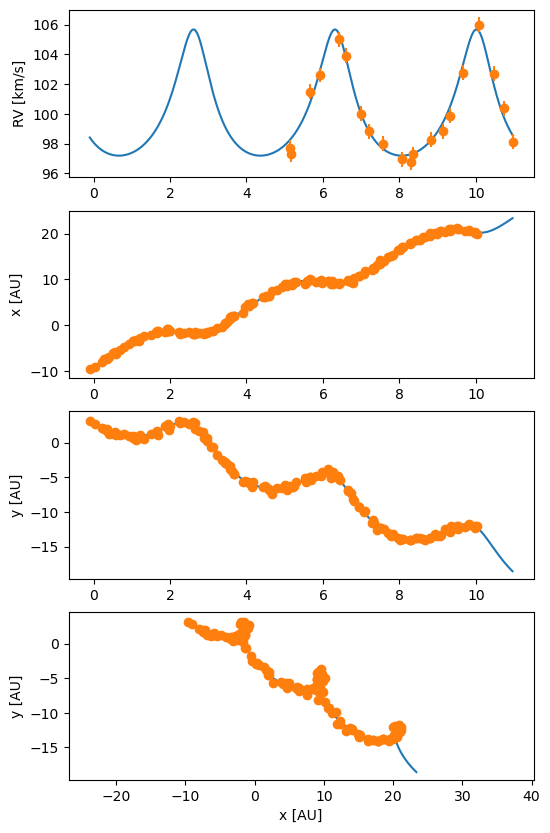

In [3]:
fig, ax = plt.subplots(4, 1, figsize=(6, 10))
ax[0].plot(t_full, rvs_full, color="C0")
ax[0].errorbar(rv.t, rv.rv, yerr=rv.rv_err, fmt="o", color="C1", label="RV data")
ax[0].set_ylabel("RV [km/s]")
ax[1].plot(t_full, x_full, color="C0")
ax[1].errorbar(astro.t, astro.x, yerr=astro.x_err, fmt="o", color="C1")
ax[1].set_ylabel("x [AU]")
ax[2].plot(t_full, y_full, color="C0")
ax[2].errorbar(astro.t, astro.y, yerr=astro.y_err, fmt="o", color="C1")
ax[2].set_ylabel("y [AU]")
ax[3].plot(x_full, y_full, color="C0")
ax[3].errorbar(astro.x, astro.y, xerr=astro.x_err, yerr=astro.y_err, fmt="o", color="C1")
ax[3].set_xlabel("x [AU]")
ax[3].set_ylabel("y [AU]")
ax[3].set_aspect("equal", adjustable="datalim")
plt.show()

## Fit

Now, fit the model using MCMC

In [4]:
priors = {
    "P": p.LogUniformPrior(0.01, 20.0),
    "e": p.UniformPrior(0.0, 0.95),
    "M0": p.UniformPrior(0.0, 2 * np.pi),
    "a2": p.LogUniformPrior(0.01, 20.0),
    "omega": p.UniformPrior(0.0, 2 * np.pi),
    "Omega": p.UniformPrior(0.0, 2 * np.pi),
    "cosi": p.UniformPrior(-1.0, 1.0),
    "dx": p.UniformPrior(-10.0, 10.0),
    "dy": p.UniformPrior(-10.0, 10.0),
    "dpmra": p.UniformPrior(-10.0, 10.0),
    "dpmdec": p.UniformPrior(-10.0, 10.0),
    "systemic_velocity": p.UniformPrior(0.0, 200.0),
    "K2": p.LogUniformPrior(0.01, 100.0),
    "Tepoch": p.FixedPrior(model["Tepoch"]),
    "M2": p.FixedPrior(model["M2"]),
}

priors_rv = {
    "P": p.LogUniformPrior(0.01, 20.0),
    "e": p.UniformPrior(0.0, 0.95),
    "omega": p.UniformPrior(0.0, 2 * np.pi),
    "M0": p.UniformPrior(0.0, 2 * np.pi),
    "K2": p.LogUniformPrior(0.01, 100.0),
    "systemic_velocity": p.UniformPrior(0.0, 200.0),
    "omega": p.UniformPrior(0.0, 2 * np.pi),
    "Tepoch": p.FixedPrior(model["Tepoch"]),
    "M2": p.FixedPrior(model["M2"]),
}

fitter = p.MCMCFitter(
    nwalkers=100,
    niter=10000,
    sample_params=["P", "e", "M0", "A2", "B2", "F2", "G2", "K2", "dx", "dy", "dpmra", "dpmdec", "systemic_velocity"],
    **priors
)

results = fitter.fit(data, rng)

100%|██████████| 10000/10000 [01:11<00:00, 140.35it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 9 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [166.93046834 776.47405584 594.0472418  546.92029397 156.14890571
 375.01862873 528.37876587 532.36750129 127.71261691 528.91756324
 271.20411993  65.1285329  596.01642727]


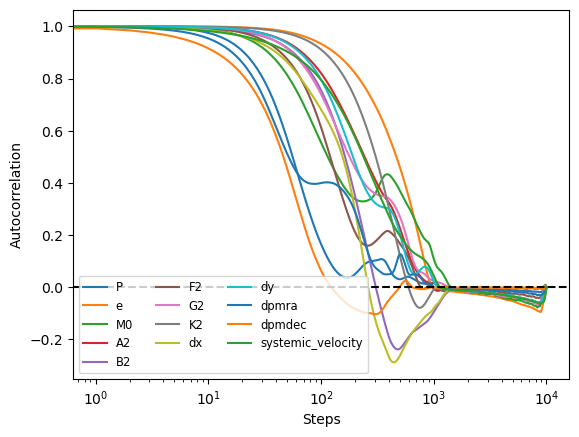

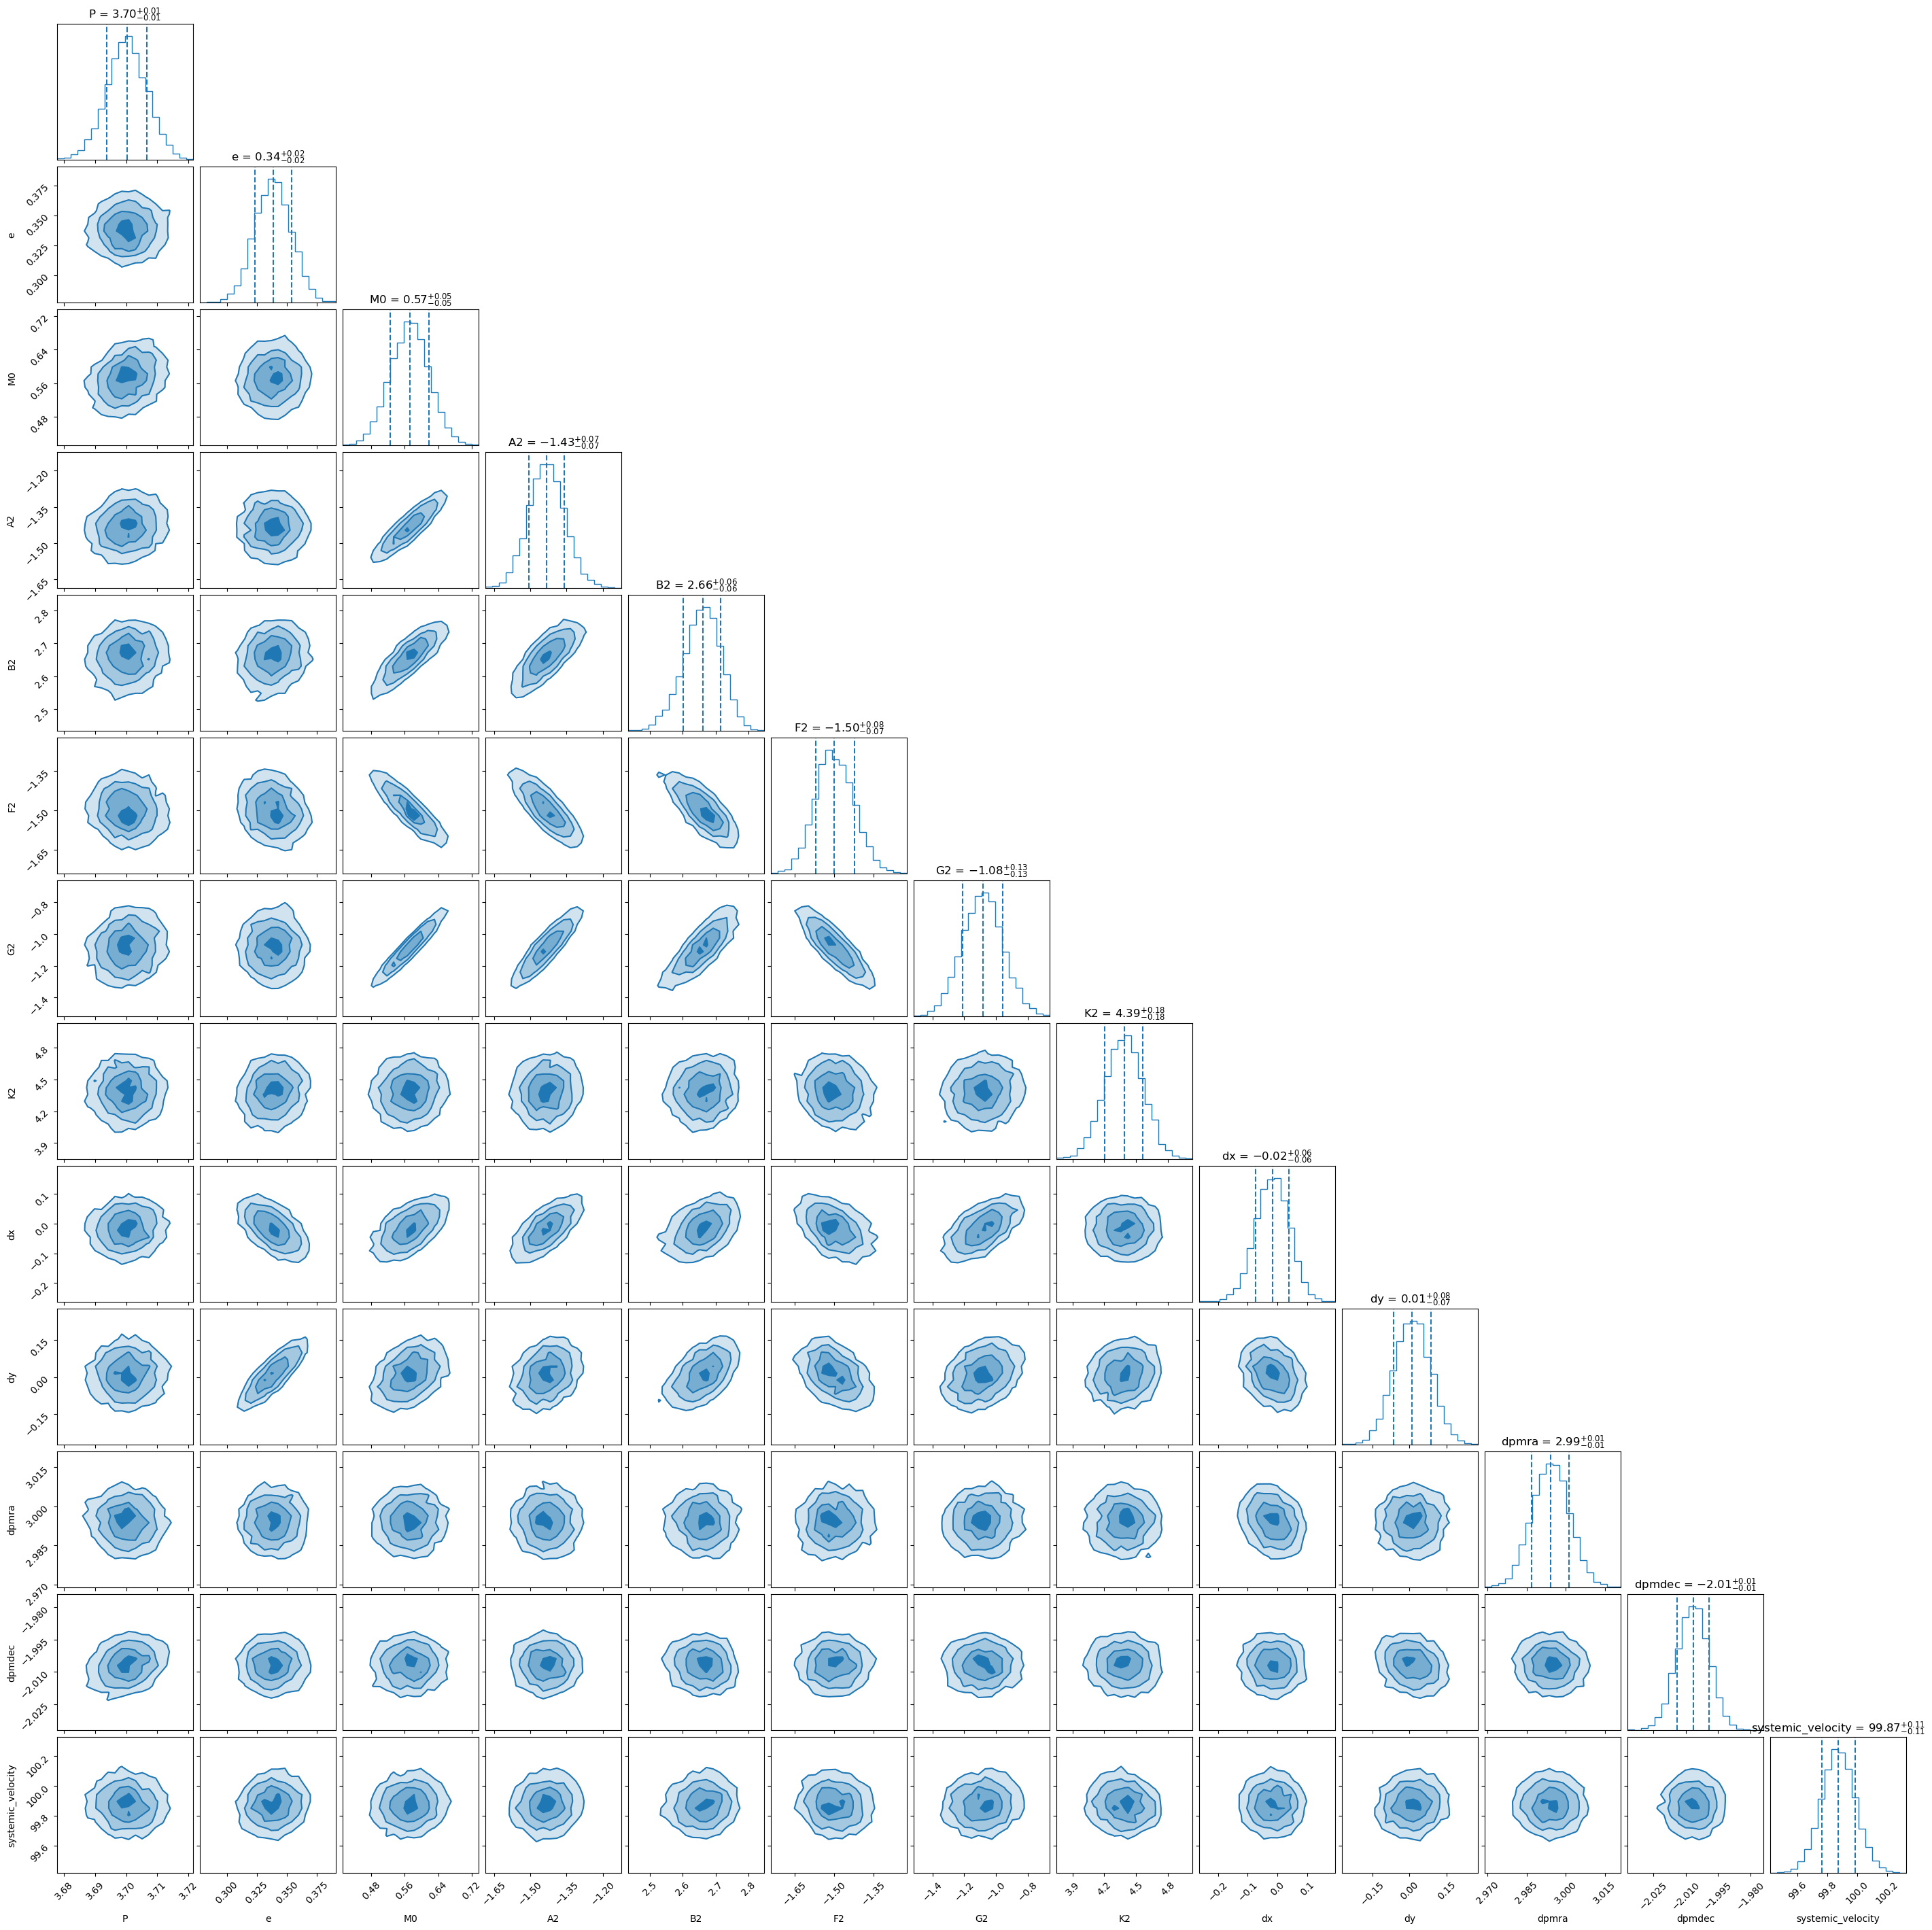

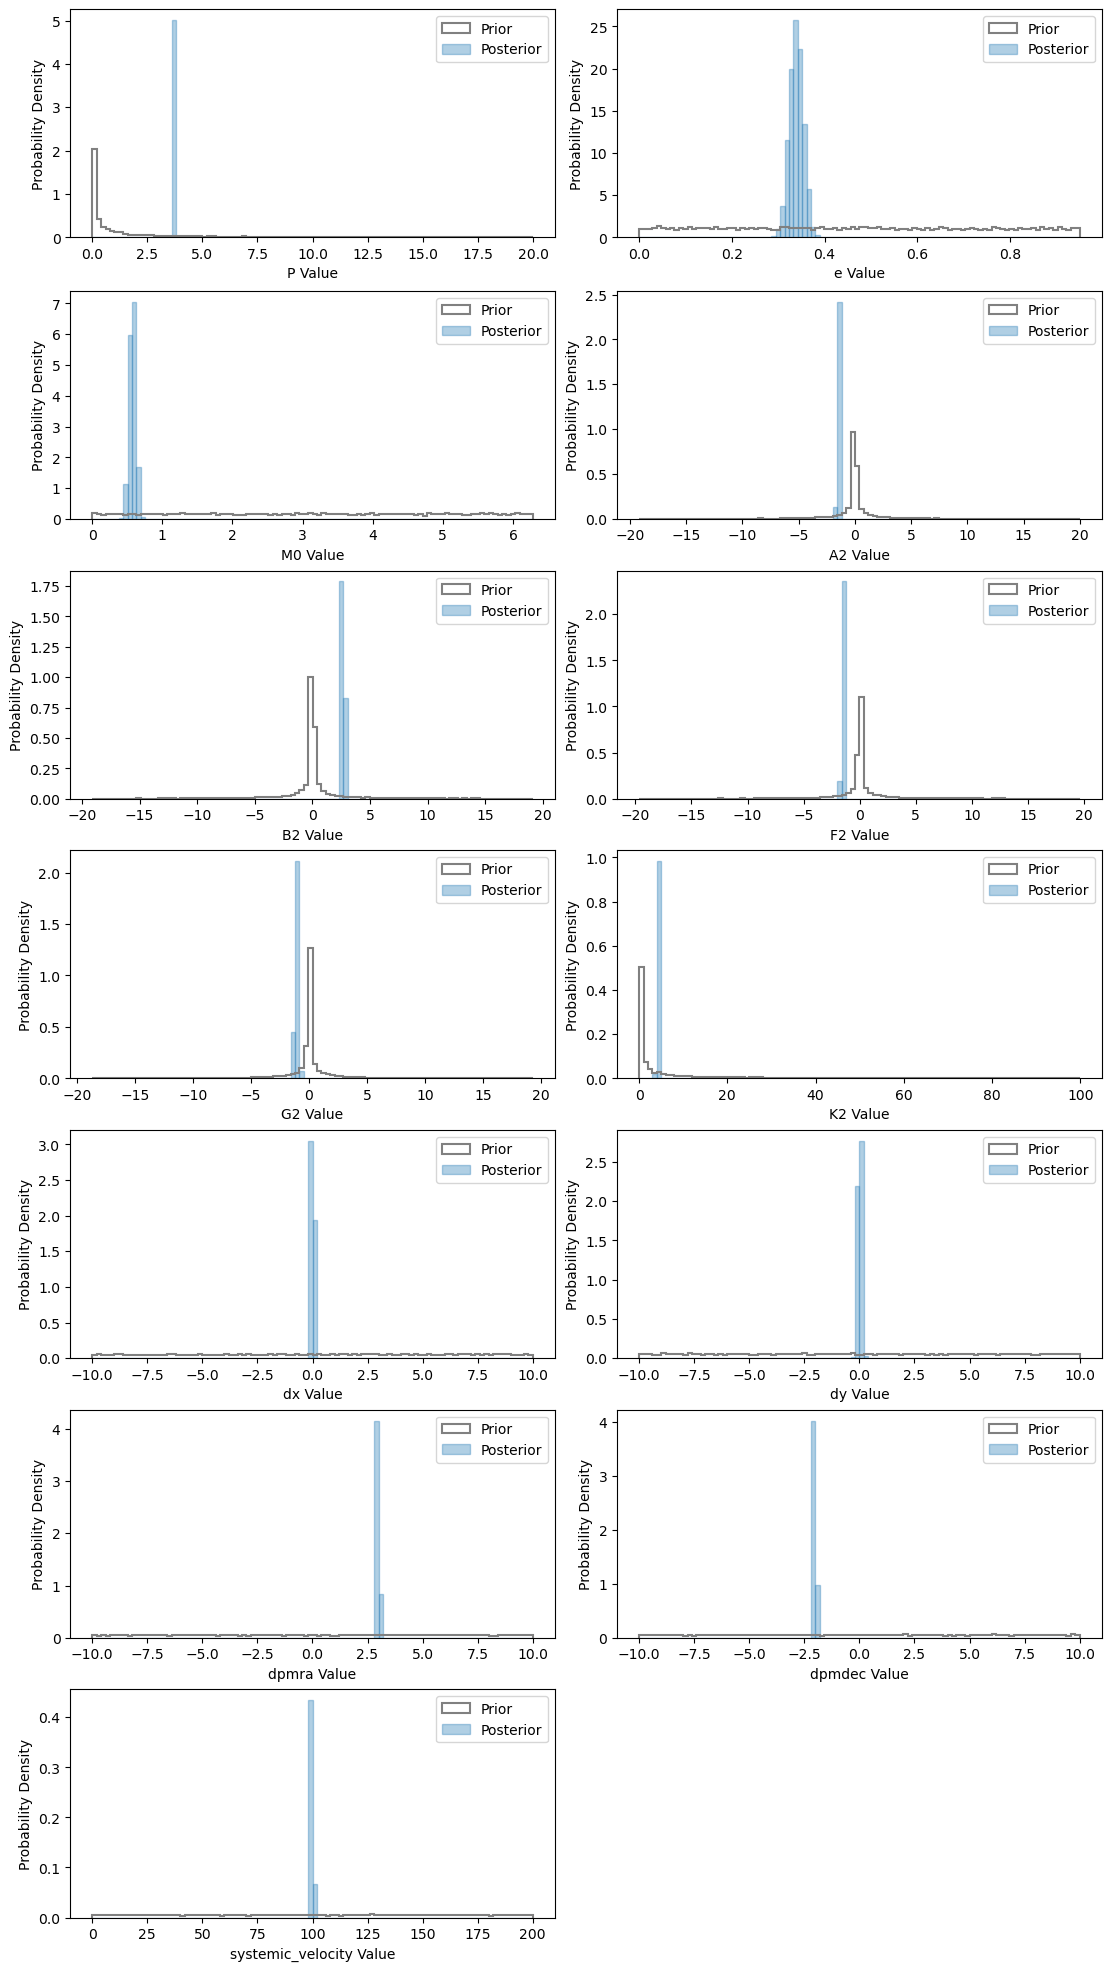

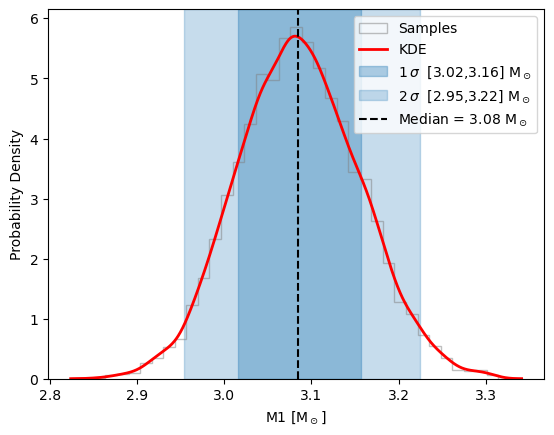

In [5]:
p.mcmc_autocorrelation_plot(results);
p.corner_plot(results);
p.posterior_over_prior(results);
p.distribution(results, "M1", unit=r"M$_\odot$");

In [6]:
rvfitter = p.MCMCFitter(
    nwalkers=100,
    niter=10000,
    sample_params=["P", "e", "M0", "omega", "K2", "systemic_velocity"],
    **priors_rv
)
rvresults = rvfitter.fit(rv, rng)

  0%|          | 0/10000 [00:00<?, ?it/s]/Users/mw/Development/miniforge3/envs/astro/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [00:23<00:00, 424.56it/s]


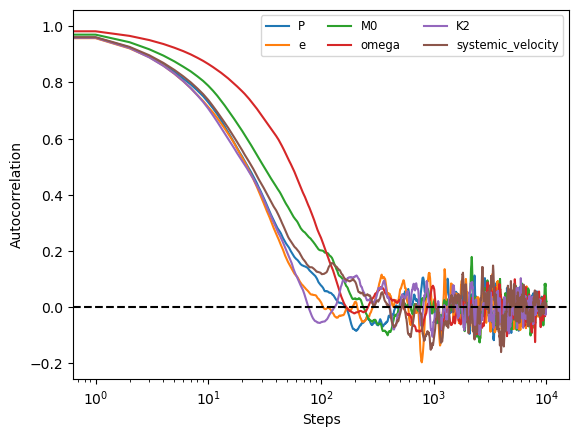

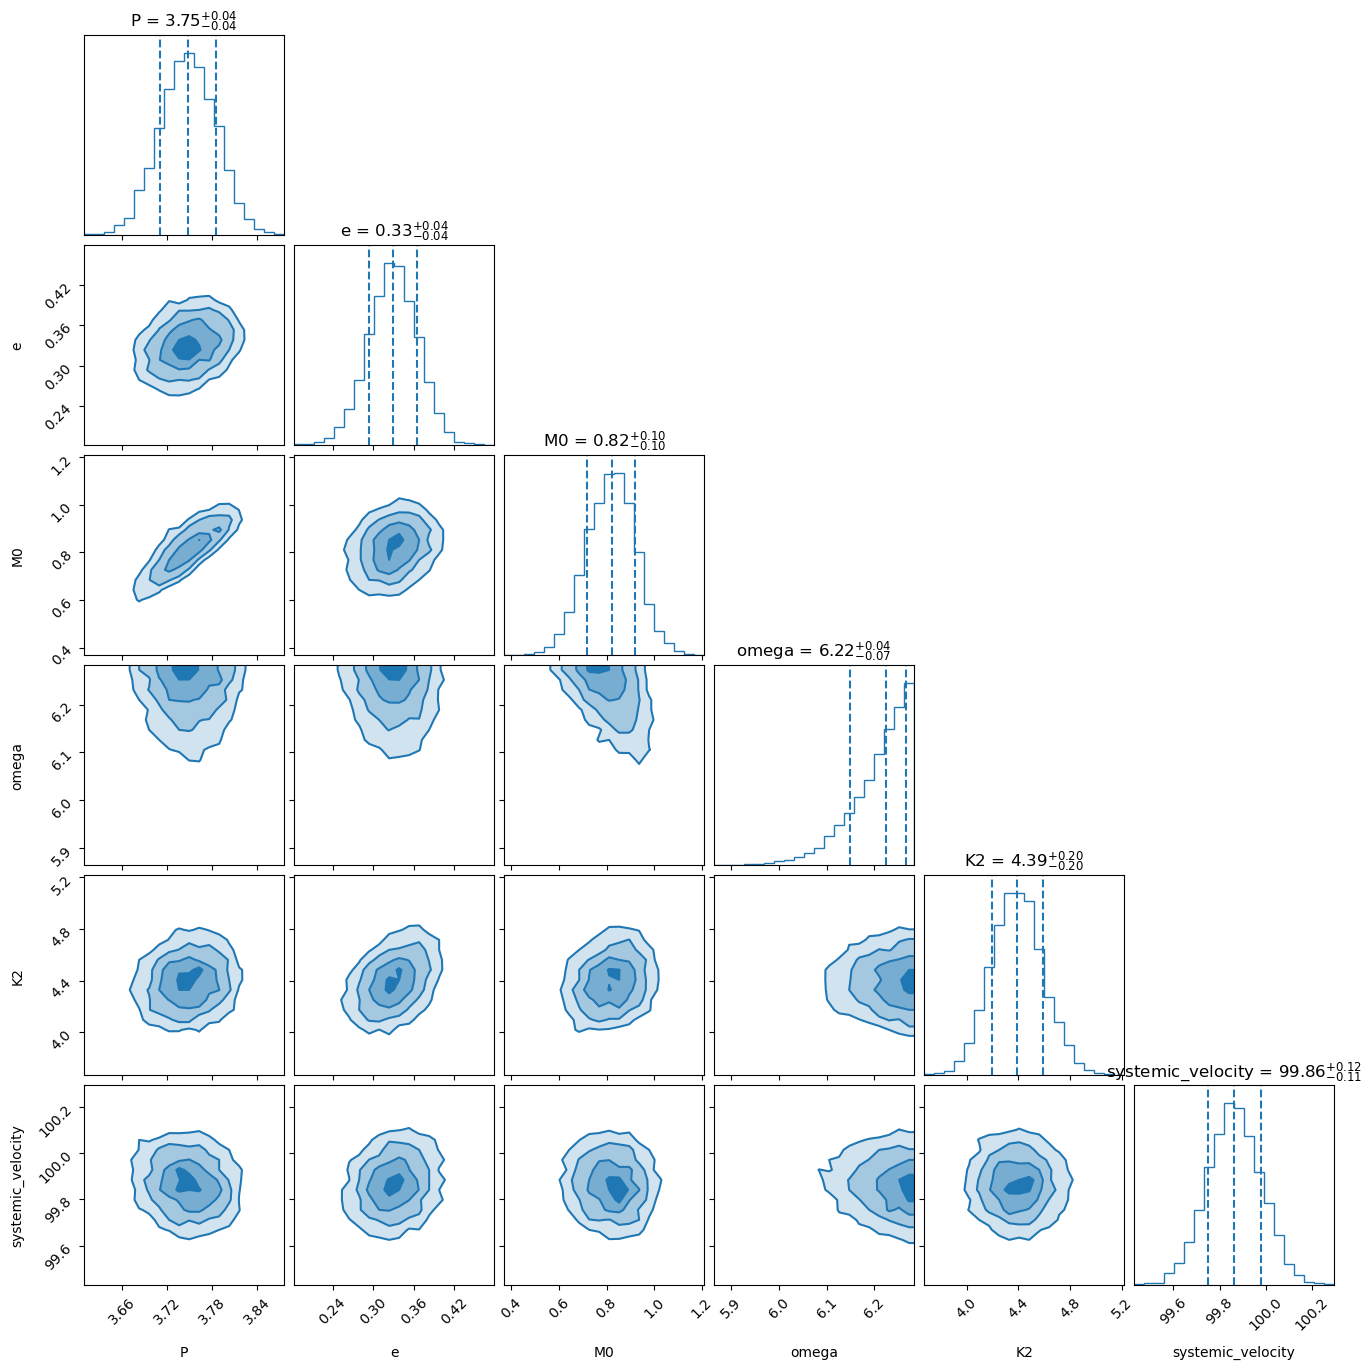

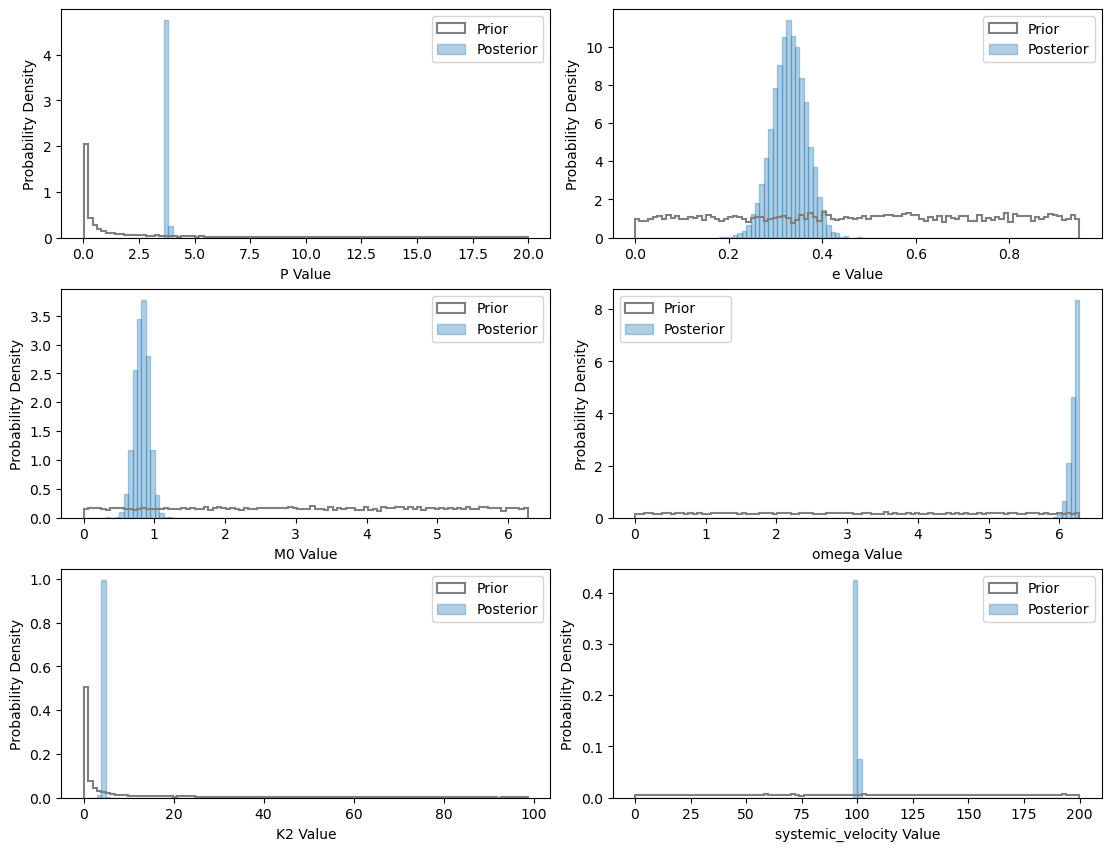

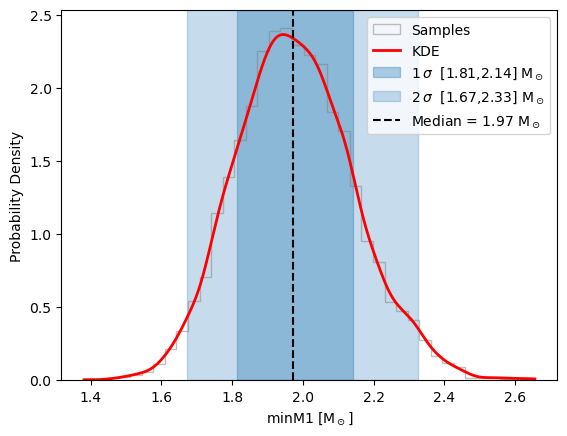

In [7]:
p.mcmc_autocorrelation_plot(rvresults);
p.corner_plot(rvresults);
p.posterior_over_prior(rvresults);
p.distribution(rvresults, "minM1", unit=r"M$_\odot$");

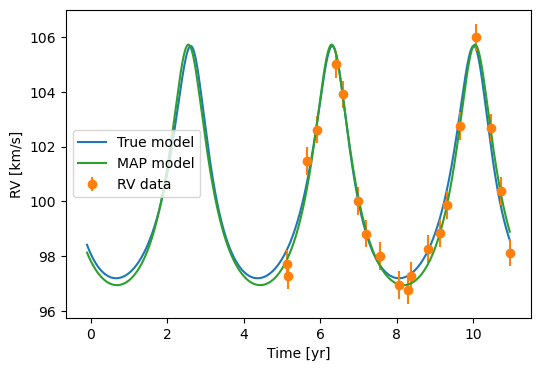

In [9]:
rv_map_params = rvresults.MAP_params
rv_map_model = p.Orbit(**rv_map_params)
plt.figure(figsize=(6, 4))
plt.plot(t_full, rvs_full, color="C0", label="True model")
plt.errorbar(rv.t, rv.rv, yerr=rv.rv_err, fmt="o", color="C1", label="RV data")
plt.plot(t_full, rv_map_model.rv(t_full, system=2), color="C2", label="MAP model")
plt.xlabel("Time [yr]")
plt.ylabel("RV [km/s]")
plt.legend()
plt.show()

In [10]:
astrofitter = p.MCMCFitter(
    nwalkers=100,
    niter=10000,
    sample_params=["P", "e", "M0", "A2", "B2", "F2", "G2", "dx", "dy", "dpmra", "dpmdec"],
    **priors
)
astroresults = astrofitter.fit(astro, rng)

/Users/mw/Research/software/periapsis/src/periapsis/fitting/mcmc.py:61: UserWarning: Some priors are not reachable from the sampled parameters and will be ignored: ['K2', 'systemic_velocity'].
  warnings.warn(f"Some priors are not reachable from the sampled parameters and will be ignored: {sorted(unreachable_priors)}.")
/Users/mw/Research/software/periapsis/src/periapsis/fitting/mcmc.py:193: UserWarning: Prior for parameter systemic_velocity is not reachable from sampled parameters or fixed parameters. It will be ignored in the posterior evaluation.
  warnings.warn(f"Prior for parameter {name} is not reachable from sampled parameters or fixed parameters. It will be ignored in the posterior evaluation.")
/Users/mw/Research/software/periapsis/src/periapsis/fitting/mcmc.py:193: UserWarning: Prior for parameter K2 is not reachable from sampled parameters or fixed parameters. It will be ignored in the posterior evaluation.
  warnings.warn(f"Prior for parameter {name} is not reachable from s

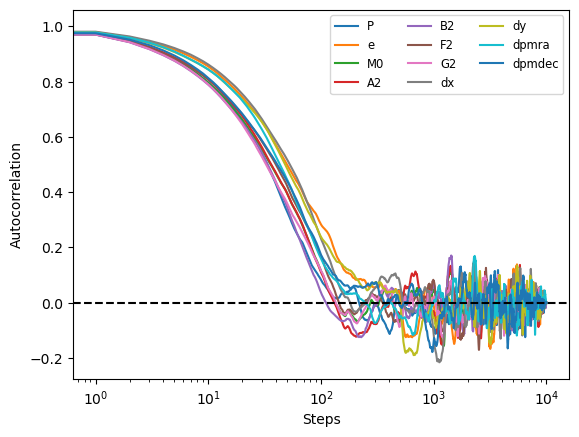

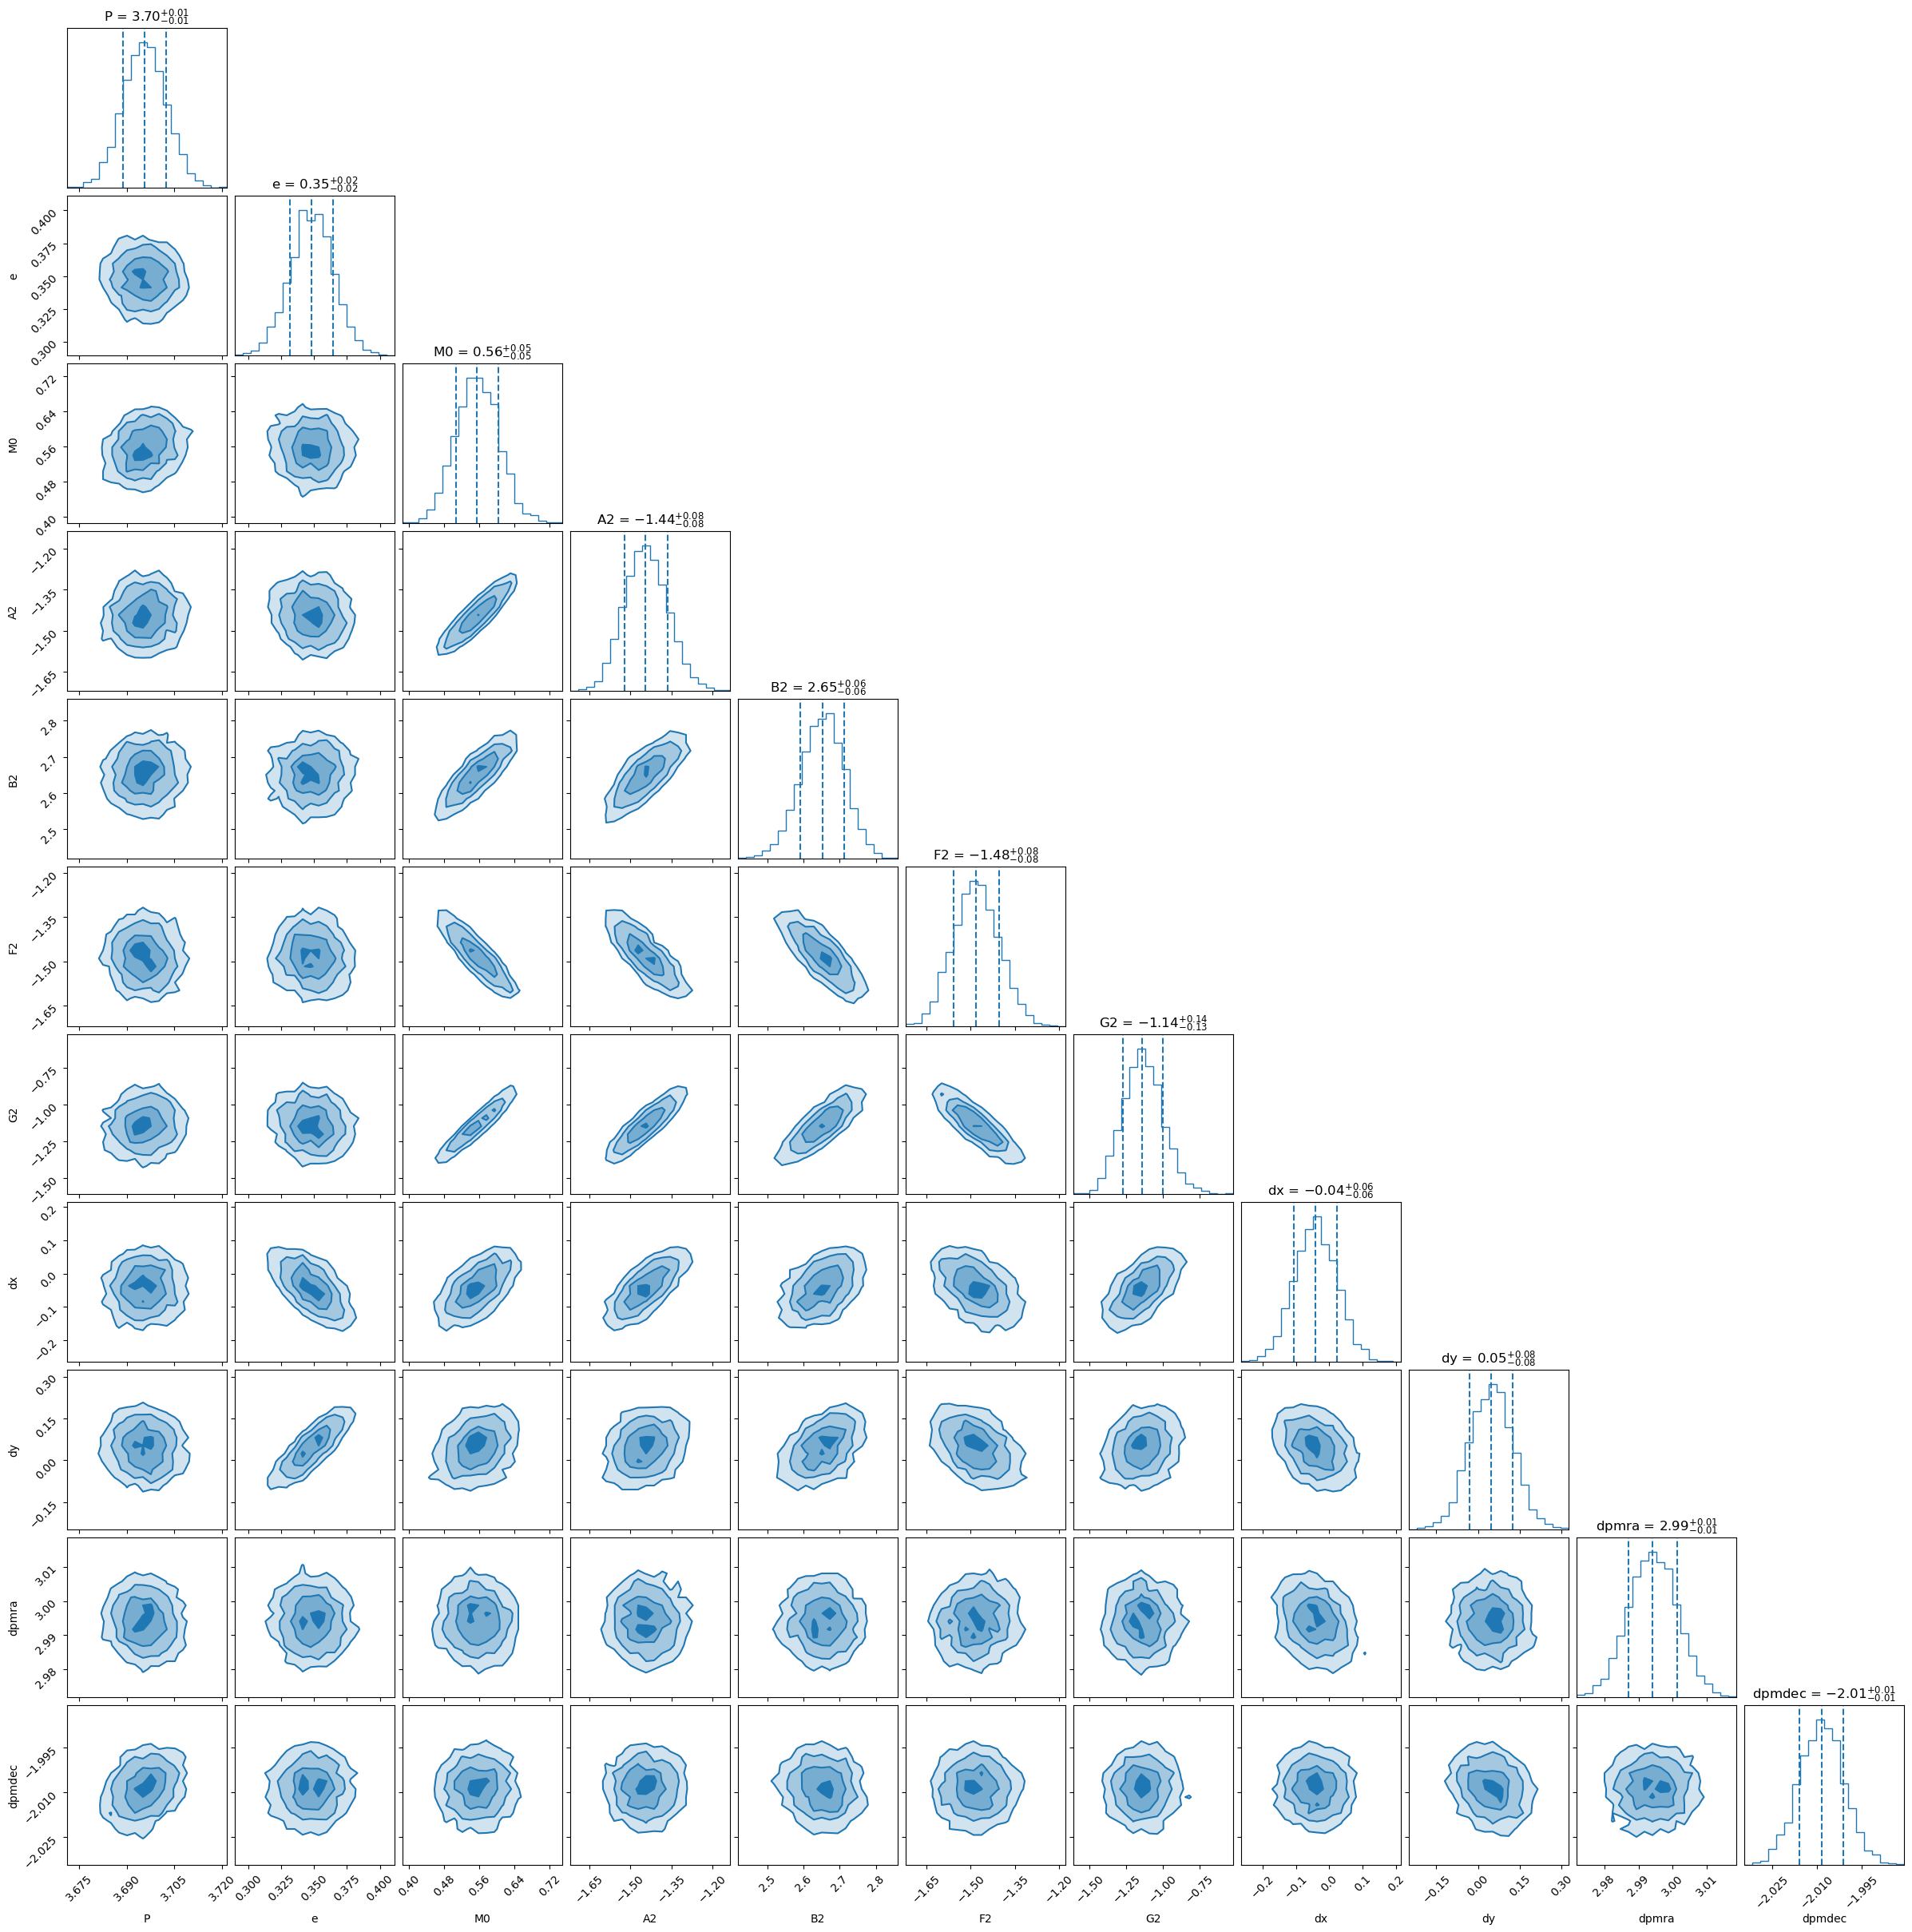

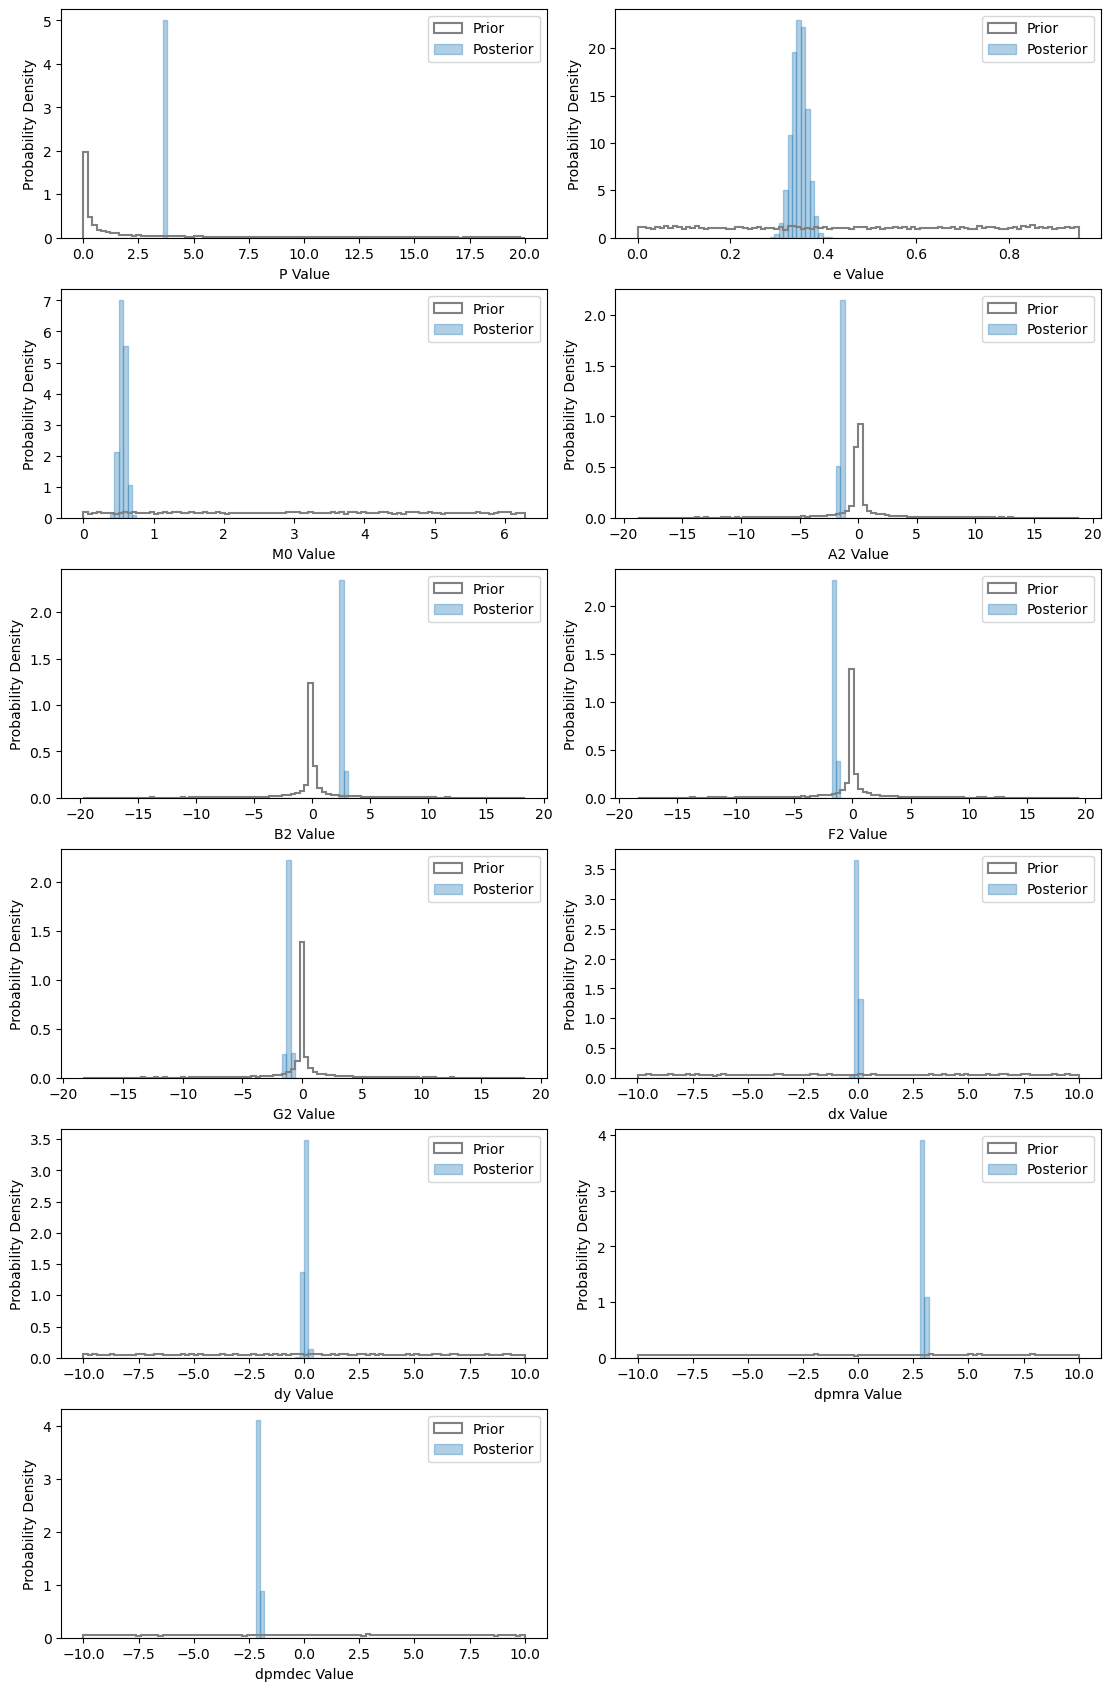

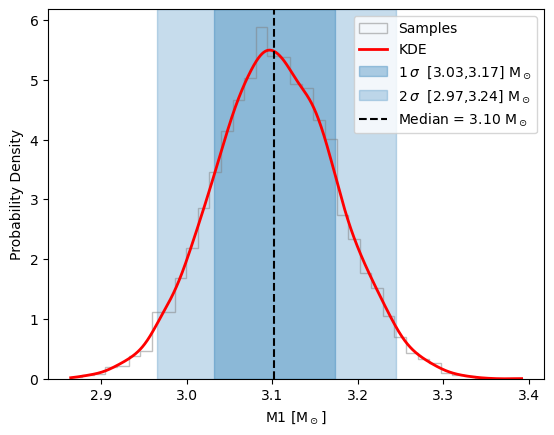

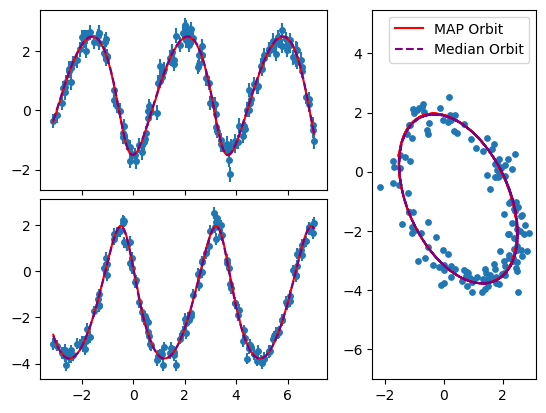

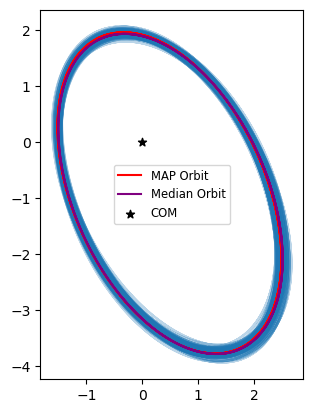

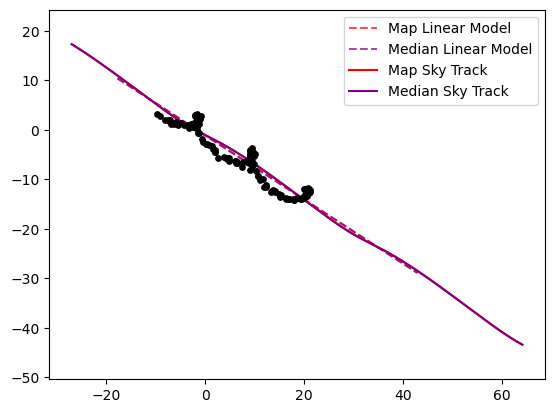

In [11]:
p.mcmc_autocorrelation_plot(astroresults);
p.corner_plot(astroresults);
p.posterior_over_prior(astroresults);
p.distribution(astroresults, "M1", unit=r"M$_\odot$");
p.orbit_plot(astroresults, astro, system=2);
p.multi_orbit_plot(astroresults, astro, system=2);
p.sky_motion_plot(astroresults, astro);

In [12]:
{
    name: model[name] for name in fitter.param_order
}

{'P': np.float64(3.6999999999999997),
 'e': 0.34,
 'M0': 0.6,
 'A2': np.float64(-1.3898642592574892),
 'B2': np.float64(2.643697339317462),
 'F2': np.float64(-1.5556694016698),
 'G2': np.float64(-1.0661261677277407),
 'K2': np.float64(4.243440120300141),
 'dx': 0.0,
 'dy': 0.0,
 'dpmra': 3.0,
 'dpmdec': -2.0,
 'systemic_velocity': 100.0}

In [13]:
astro_guess = p.AstrometryInitialGuess(astro, rng, **priors).get_initial_guess(fitter.param_order, 1).flatten()
{
    name: astro_guess[i] for i, name in enumerate(fitter.param_order)
}

{'P': np.float64(3.6955443847785867),
 'e': np.float64(0.3480186432153563),
 'M0': np.float64(0.5570408077938291),
 'A2': np.float64(-1.4404822926267007),
 'B2': np.float64(2.655847306892329),
 'F2': np.float64(-1.4841894927353907),
 'G2': np.float64(-1.1349275567929158),
 'K2': np.float64(0.009962553113255009),
 'dx': np.float64(-0.04047386807178293),
 'dy': np.float64(0.049008461912616964),
 'dpmra': np.float64(2.994152109099806),
 'dpmdec': np.float64(-2.0084245444387894),
 'systemic_velocity': np.float64(98.5994578068556)}

In [14]:
rv_guess = p.RVInitialGuess(rv, rng, **priors).get_initial_guess(fitter.param_order, 1).flatten()
{
    name: rv_guess[i] for i, name in enumerate(fitter.param_order)
}

{'P': np.float64(3.749543068165347),
 'e': np.float64(0.3250582852390905),
 'M0': np.float64(0.7061813768909403),
 'A2': np.float64(-0.005260232960679944),
 'B2': np.float64(-0.008182885066885293),
 'F2': np.float64(-0.0020158376412178288),
 'G2': np.float64(0.00202561794672762),
 'K2': np.float64(4.383061232302576),
 'dx': np.float64(-9.650498482878888),
 'dy': np.float64(-3.9569672976878394),
 'dpmra': np.float64(-2.5451153765428294),
 'dpmdec': np.float64(7.929215205987279),
 'systemic_velocity': np.float64(99.83818334695114)}

In [15]:
joint_guess = p.JointInitialGuess(data, rng, **priors).get_initial_guess(fitter.param_order, 1).flatten()

for i, name in enumerate(fitter.param_order):
    print(f"{name}:\n\t{joint_guess[i]:.3f},\t{model[name]:.3f},\t{joint_guess[i] - model[name]:.4f}")

P:
	3.722,	3.700,	0.0224
e:
	0.337,	0.340,	-0.0034
M0:
	0.632,	0.600,	0.0318
A2:
	-0.725,	-1.390,	0.6649
B2:
	1.330,	2.644,	-1.3140
F2:
	-0.743,	-1.556,	0.8127
G2:
	-0.571,	-1.066,	0.4956
K2:
	2.196,	4.243,	-2.0470
dx:
	-0.984,	0.000,	-0.9839
dy:
	1.162,	0.000,	1.1617
dpmra:
	3.602,	3.000,	0.6023
dpmdec:
	-4.051,	-2.000,	-2.0506
systemic_velocity:
	115.157,	100.000,	15.1575
